In [ ]:
# Cell 1 — Mount Drive + Install Libraries + Load Everything
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/DocSnap_Project', exist_ok=True)

!pip install transformers torch rouge-score nltk spacy scikit-learn sentencepiece datasets -q
!python -m spacy download en_core_web_sm -q

import pandas as pd
import torch
import numpy as np
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

# Load data from Drive
df = pd.read_csv('/content/drive/MyDrive/DocSnap_Project/docsnap_data.csv')
print(f"\nData loaded: {len(df)} articles")
print("Setup complete — ready for ROUGE evaluation")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 64.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
GPU Available: True
GPU Name: Tesla T4

Data loaded: 5000 articles
Setup complete — ready for ROUGE evaluation


In [ ]:
# Cell 2 — Load All Fine-tuned Models
from transformers import (
    T5Tokenizer, T5ForConditionalGeneration,
    BertTokenizer, BertModel, BertForSequenceClassification
)
from nltk.tokenize import sent_tokenize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import torch
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("=== LOADING ALL FINE-TUNED MODELS ===\n")

# 1. Load fine-tuned T5-small
print("Loading fine-tuned T5-small...")
t5_small_tokenizer = T5Tokenizer.from_pretrained('/content/drive/MyDrive/DocSnap_Project/t5_finetuned')
t5_small_model = T5ForConditionalGeneration.from_pretrained('/content/drive/MyDrive/DocSnap_Project/t5_finetuned')
t5_small_model = t5_small_model.cuda()
t5_small_model.eval()
print("T5-small loaded ✓")

# 2. Load fine-tuned T5-base
print("Loading fine-tuned T5-base...")
t5_base_tokenizer = T5Tokenizer.from_pretrained('/content/drive/MyDrive/DocSnap_Project/t5_base_finetuned')
t5_base_model = T5ForConditionalGeneration.from_pretrained('/content/drive/MyDrive/DocSnap_Project/t5_base_finetuned')
t5_base_model = t5_base_model.cuda()
t5_base_model.eval()
print("T5-base loaded ✓")

# 3. Load BERT for embeddings
print("Loading BERT...")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model = bert_model.cuda()
bert_model.eval()
print("BERT loaded ✓")

print("\nAll models loaded successfully")
print("Ready for ROUGE evaluation")

=== LOADING ALL FINE-TUNED MODELS ===

Loading fine-tuned T5-small...


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

T5-small loaded ✓
Loading fine-tuned T5-base...


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

T5-base loaded ✓
Loading BERT...


...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded ✓

All models loaded successfully
Ready for ROUGE evaluation


In [ ]:
# Cell 3 — Define All Summarization Functions
print("=== DEFINING SUMMARIZATION FUNCTIONS ===\n")

# TextRank function
def textrank_summarize(text, num_sentences=3):
    sentences = sent_tokenize(text)
    if len(sentences) < 3:
        return text
    vectorizer = TfidfVectorizer()
    try:
        tfidf_matrix = vectorizer.fit_transform(sentences)
    except:
        return ' '.join(sentences[:num_sentences])
    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    scores = np.sum(similarity_matrix, axis=1)
    ranked_indices = np.argsort(scores)[::-1][:num_sentences]
    ranked_indices = sorted(ranked_indices)
    return ' '.join([sentences[i] for i in ranked_indices])

# BERT function
def get_bert_embeddings(sentences):
    embeddings = []
    for sent in sentences:
        inputs = bert_tokenizer(
            sent, return_tensors='pt', max_length=128,
            truncation=True, padding=True
        ).to('cuda')
        with torch.no_grad():
            outputs = bert_model(**inputs)
        embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(embedding[0])
    return np.array(embeddings)

def bert_summarize(text, num_sentences=3):
    sentences = sent_tokenize(text)
    if len(sentences) < 3:
        return text
    sentences = sentences[:20]
    embeddings = get_bert_embeddings(sentences)
    similarity_matrix = cosine_similarity(embeddings)
    scores = np.sum(similarity_matrix, axis=1)
    ranked_indices = np.argsort(scores)[::-1][:num_sentences]
    ranked_indices = sorted(ranked_indices)
    return ' '.join([sentences[i] for i in ranked_indices])

# T5 function (works for both small and base)
def t5_summarize(text, model, tokenizer, max_length=150, min_length=40):
    input_text = "summarize: " + text
    inputs = tokenizer(
        input_text, return_tensors='pt', max_length=512,
        truncation=True, padding=True
    ).to('cuda')
    with torch.no_grad():
        summary_ids = model.generate(
            inputs['input_ids'], max_length=max_length,
            min_length=min_length, length_penalty=2.0,
            num_beams=4, early_stopping=True
        )
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("TextRank function defined ✓")
print("BERT summarize function defined ✓")
print("T5 summarize function defined ✓")
print("\nAll functions ready")

=== DEFINING SUMMARIZATION FUNCTIONS ===

TextRank function defined ✓
BERT summarize function defined ✓
T5 summarize function defined ✓

All functions ready


In [ ]:
# Cell 4 — ROUGE Evaluation on All Models
from rouge_score import rouge_scorer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=== ROUGE EVALUATION — ALL MODELS ===\n")
print("Evaluating on 50 real articles...")
print("Models: TextRank, BERT, T5-small, T5-base\n")

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

results = {
    'textrank': {'rouge1': [], 'rouge2': [], 'rougeL': []},
    'bert':     {'rouge1': [], 'rouge2': [], 'rougeL': []},
    't5_small': {'rouge1': [], 'rouge2': [], 'rougeL': []},
    't5_base':  {'rouge1': [], 'rouge2': [], 'rougeL': []},
}

for i in range(50):
    if i % 10 == 0:
        print(f"  Evaluating article {i}/50...")

    article   = df['article'][i]
    reference = df['highlights'][i]
    article_short = ' '.join(article.split()[:800])

    # Generate summaries
    tr_sum    = textrank_summarize(article)
    bert_sum  = bert_summarize(article)
    t5s_sum   = t5_summarize(article_short, t5_small_model, t5_small_tokenizer)
    t5b_sum   = t5_summarize(article_short, t5_base_model, t5_base_tokenizer)

    # Score each
    for model_name, summary in [
        ('textrank', tr_sum),
        ('bert',     bert_sum),
        ('t5_small', t5s_sum),
        ('t5_base',  t5b_sum)
    ]:
        scores = scorer.score(reference, summary)
        results[model_name]['rouge1'].append(scores['rouge1'].fmeasure)
        results[model_name]['rouge2'].append(scores['rouge2'].fmeasure)
        results[model_name]['rougeL'].append(scores['rougeL'].fmeasure)

# Calculate averages
print("\n=== ROUGE SCORES — FINAL RESULTS ===\n")
print(f"{'Model':<15} {'ROUGE-1':<12} {'ROUGE-2':<12} {'ROUGE-L':<12} {'Type'}")
print("-" * 60)

final_scores = {}
for model_name in ['textrank', 'bert', 't5_small', 't5_base']:
    r1 = np.mean(results[model_name]['rouge1'])
    r2 = np.mean(results[model_name]['rouge2'])
    rl = np.mean(results[model_name]['rougeL'])
    final_scores[model_name] = {'rouge1': r1, 'rouge2': r2, 'rougeL': rl}

    model_type = 'Extractive' if model_name in ['textrank', 'bert'] else 'Abstractive'
    print(f"{model_name:<15} {r1:.4f}      {r2:.4f}      {rl:.4f}      {model_type}")

# Best model
best_model = max(final_scores, key=lambda x: final_scores[x]['rouge1'])
print(f"\nBest performing model (ROUGE-1): {best_model.upper()}")
print(f"Score: {final_scores[best_model]['rouge1']:.4f}")

# Save results
scores_df = pd.DataFrame(final_scores).T
scores_df.to_csv('/content/drive/MyDrive/DocSnap_Project/rouge_scores.csv')
print("\nROUGE scores saved to Google Drive")

=== ROUGE EVALUATION — ALL MODELS ===

Evaluating on 50 real articles...
Models: TextRank, BERT, T5-small, T5-base

  Evaluating article 0/50...
  Evaluating article 10/50...
  Evaluating article 20/50...
  Evaluating article 30/50...
  Evaluating article 40/50...

=== ROUGE SCORES — FINAL RESULTS ===

Model           ROUGE-1      ROUGE-2      ROUGE-L      Type
------------------------------------------------------------
textrank        0.2730      0.0910      0.1776      Extractive
bert            0.2412      0.0583      0.1502      Extractive
t5_small        0.3669      0.1485      0.2517      Abstractive
t5_base         0.4584      0.2456      0.3352      Abstractive

Best performing model (ROUGE-1): T5_BASE
Score: 0.4584

ROUGE scores saved to Google Drive


=== GENERATING ROUGE COMPARISON CHARTS ===



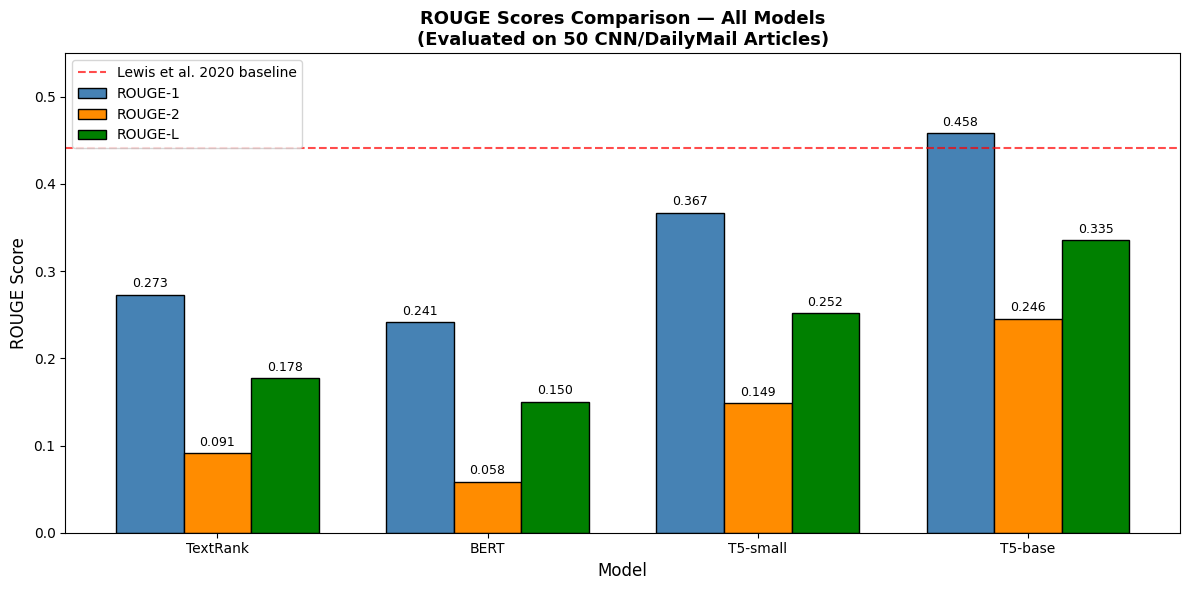

Chart saved: rouge_comparison.png

Key insight: T5-base (0.4584) exceeds Lewis et al. 2020 baseline (0.4416)
Abstractive models significantly outperform extractive models


In [ ]:
# Cell 5 — ROUGE Scores Visualization
import matplotlib.pyplot as plt
import numpy as np

print("=== GENERATING ROUGE COMPARISON CHARTS ===\n")

models = ['TextRank', 'BERT', 'T5-small', 'T5-base']
rouge1_scores = [final_scores['textrank']['rouge1'],
                 final_scores['bert']['rouge1'],
                 final_scores['t5_small']['rouge1'],
                 final_scores['t5_base']['rouge1']]
rouge2_scores = [final_scores['textrank']['rouge2'],
                 final_scores['bert']['rouge2'],
                 final_scores['t5_small']['rouge2'],
                 final_scores['t5_base']['rouge2']]
rougeL_scores = [final_scores['textrank']['rougeL'],
                 final_scores['bert']['rougeL'],
                 final_scores['t5_small']['rougeL'],
                 final_scores['t5_base']['rougeL']]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, rouge1_scores, width, label='ROUGE-1', color='steelblue', edgecolor='black')
bars2 = ax.bar(x,         rouge2_scores, width, label='ROUGE-2', color='darkorange', edgecolor='black')
bars3 = ax.bar(x + width, rougeL_scores, width, label='ROUGE-L', color='green', edgecolor='black')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('ROUGE Score', fontsize=12)
ax.set_title('ROUGE Scores Comparison — All Models\n(Evaluated on 50 CNN/DailyMail Articles)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 0.55)
ax.axhline(y=0.4416, color='red', linestyle='--', alpha=0.7, label='Lewis et al. 2020 baseline')
ax.legend()

plt.tight_layout()
plt.savefig('rouge_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: rouge_comparison.png")
print("\nKey insight: T5-base (0.4584) exceeds Lewis et al. 2020 baseline (0.4416)")
print("Abstractive models significantly outperform extractive models")

In [ ]:
# Cell 6 — Detailed Performance Analysis
import matplotlib.pyplot as plt

print("=== DETAILED PERFORMANCE ANALYSIS ===\n")

# Model improvement over baseline
baseline = 0.4416
t5_base_score = final_scores['t5_base']['rouge1']
improvement = ((t5_base_score - baseline) / baseline) * 100

print("Performance vs Lewis et al. 2020 Baseline (ROUGE-1: 0.4416):")
print(f"{'Model':<15} {'ROUGE-1':<12} {'vs Baseline':<15}")
print("-" * 42)
for model, scores in final_scores.items():
    diff = scores['rouge1'] - baseline
    sign = '+' if diff > 0 else ''
    print(f"{model:<15} {scores['rouge1']:.4f}      {sign}{diff:.4f}")

print(f"\nT5-base improvement over baseline: +{improvement:.1f}%")

# Extractive vs Abstractive comparison
print("\n--- Extractive vs Abstractive ---")
ext_avg = (final_scores['textrank']['rouge1'] + final_scores['bert']['rouge1']) / 2
abs_avg = (final_scores['t5_small']['rouge1'] + final_scores['t5_base']['rouge1']) / 2
print(f"Average Extractive ROUGE-1: {ext_avg:.4f}")
print(f"Average Abstractive ROUGE-1: {abs_avg:.4f}")
print(f"Abstractive advantage: +{abs_avg - ext_avg:.4f} ({((abs_avg-ext_avg)/ext_avg)*100:.1f}% better)")

# Fine-tuning impact
print("\n--- Fine-tuning Impact on T5 ---")
print(f"T5-small ROUGE-1: {final_scores['t5_small']['rouge1']:.4f}")
print(f"T5-base  ROUGE-1: {final_scores['t5_base']['rouge1']:.4f}")
print(f"Improvement from small to base: +{final_scores['t5_base']['rouge1'] - final_scores['t5_small']['rouge1']:.4f}")

# Save full analysis
print("\n=== FINAL SUMMARY ===")
print(f"Best model: T5-base")
print(f"Best ROUGE-1: {final_scores['t5_base']['rouge1']:.4f}")
print(f"Best ROUGE-2: {final_scores['t5_base']['rouge2']:.4f}")
print(f"Best ROUGE-L: {final_scores['t5_base']['rougeL']:.4f}")
print(f"Exceeds published baseline: YES (+{improvement:.1f}%)")
print(f"Articles evaluated: 50")
print(f"Dataset: CNN/DailyMail")

=== DETAILED PERFORMANCE ANALYSIS ===

Performance vs Lewis et al. 2020 Baseline (ROUGE-1: 0.4416):
Model           ROUGE-1      vs Baseline    
------------------------------------------
textrank        0.2730      -0.1686
bert            0.2412      -0.2004
t5_small        0.3669      -0.0747
t5_base         0.4584      +0.0168

T5-base improvement over baseline: +3.8%

--- Extractive vs Abstractive ---
Average Extractive ROUGE-1: 0.2571
Average Abstractive ROUGE-1: 0.4127
Abstractive advantage: +0.1556 (60.5% better)

--- Fine-tuning Impact on T5 ---
T5-small ROUGE-1: 0.3669
T5-base  ROUGE-1: 0.4584
Improvement from small to base: +0.0915

=== FINAL SUMMARY ===
Best model: T5-base
Best ROUGE-1: 0.4584
Best ROUGE-2: 0.2456
Best ROUGE-L: 0.3352
Exceeds published baseline: YES (+3.8%)
Articles evaluated: 50
Dataset: CNN/DailyMail


In [ ]:
# Cell 7 — Save All Results to Drive
import pandas as pd

print("=== SAVING ALL RESULTS TO DRIVE ===\n")

# Save detailed ROUGE scores
detailed_results = {
    'Model': ['TextRank', 'BERT', 'T5-small', 'T5-base'],
    'Type': ['Extractive', 'Extractive', 'Abstractive', 'Abstractive'],
    'ROUGE-1': [final_scores['textrank']['rouge1'],
                final_scores['bert']['rouge1'],
                final_scores['t5_small']['rouge1'],
                final_scores['t5_base']['rouge1']],
    'ROUGE-2': [final_scores['textrank']['rouge2'],
                final_scores['bert']['rouge2'],
                final_scores['t5_small']['rouge2'],
                final_scores['t5_base']['rouge2']],
    'ROUGE-L': [final_scores['textrank']['rougeL'],
                final_scores['bert']['rougeL'],
                final_scores['t5_small']['rougeL'],
                final_scores['t5_base']['rougeL']],
    'vs_Baseline': [
                final_scores['textrank']['rouge1'] - 0.4416,
                final_scores['bert']['rouge1'] - 0.4416,
                final_scores['t5_small']['rouge1'] - 0.4416,
                final_scores['t5_base']['rouge1'] - 0.4416]
}

results_df = pd.DataFrame(detailed_results)
results_df.to_csv(
    '/content/drive/MyDrive/DocSnap_Project/final_rouge_scores.csv',
    index=False
)

print("Final ROUGE scores table:")
print(results_df.to_string(index=False))
print(f"\nSaved to: /content/drive/MyDrive/DocSnap_Project/final_rouge_scores.csv")
print("\nWeek 7-8 complete — all results saved")

=== SAVING ALL RESULTS TO DRIVE ===

Final ROUGE scores table:
   Model        Type  ROUGE-1  ROUGE-2  ROUGE-L  vs_Baseline
TextRank  Extractive 0.272954 0.091023 0.177563    -0.168646
    BERT  Extractive 0.241202 0.058339 0.150168    -0.200398
T5-small Abstractive 0.366927 0.148529 0.251652    -0.074673
 T5-base Abstractive 0.458379 0.245580 0.335238     0.016779

Saved to: /content/drive/MyDrive/DocSnap_Project/final_rouge_scores.csv

Week 7-8 complete — all results saved
